# **SDG goal 8 Promote sustained, inclusive and sustainable economic growth, full and productive employment and decent work for all**
---
## **Hi all!!!**
***Today, the main focus of this analysis and prediction is centered around UNSGD goal 8 titled Decent Work and Economic growth, and my main focus is to see how the Nigerian Economy sees work, employment and also what the UNSDG goal 8 is trying to solve and possible ways for it to be solved.***
---
***So let's goooooooo!!!***

In [1]:
# Firstly, i am going to import all necessary libraries for this analysis and prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Then, I'll Load the dataset needed and skip some rows cos when i reviewed the dataset,
# It had some rows that would conflict numpy if i had continued like that.
# And i am only going to load the one for Nigeria as other countries are there.

world_bank = pd.read_csv("API_SL.UEM.1524.ZS_DS2_en_csv_v2_331568.csv", skiprows=4)
nigeria = world_bank[world_bank["Country Name"] == "Nigeria"]

In [3]:
nigeria.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
173,Nigeria,NGA,"Unemployment, youth total (% of total labor fo...",SL.UEM.1524.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN


In [4]:
nigeria.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.00,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.707,10.138,10.418,10.842,8.991,6.024,5.131,5.088,5.34,NaN


In [5]:
# As you could see above, the dataset didn't make much sense, so i'll try to structure it so that it would look better and easier to proceed with our findings 
# This is just to keep only my year columns cos it could be confusing to use the default
# Why? Before reshaping or carrying on, we need to know which columns are year columns (as opposed to "Country Name", "Country Code", etc). This line builds a list of just the columns whose names are pure numbers ("1991", "1992"...) in the dataset
year_columns = [col for col in world_bank.columns if col.isdigit()]

In [6]:
# I am going to use melt in other to break the data structure into a more suitable rows and columns in other to proceed with this analysis
nigeria_long = nigeria.melt(id_vars=["Country Name"], value_vars=year_columns,
                           var_name="Year", value_name="Youth_Unemployment_Rate")

# This line was done because even though "Year" now holds things like 1991, pandas still thinks of them as text because they came from column headers, which are always text.
nigeria_long["Year"] = nigeria_long["Year"].astype(int)

# With this, i'm dropping years with no data eg(1960:NaN)
nigeria_long = nigeria_long.dropna()

# I am doing this because after melting (nigeria.melt), rows aren't guaranteed to be in year order. Sorting makes sure our eventual line chart draws left-to-right chronologically instead of jumping around.
nigeria_long = nigeria_long.sort_values("Year")

nigeria_long

,Country Name,Year,Youth_Unemployment_Rate
31,Nigeria,1991,7.426
32,Nigeria,1992,7.242
33,Nigeria,1993,7.556
34,Nigeria,1994,7.580
35,Nigeria,1995,7.700
36,Nigeria,1996,7.542
37,Nigeria,1997,7.452
38,Nigeria,1998,7.410
39,Nigeria,1999,7.552
40,Nigeria,2000,7.571


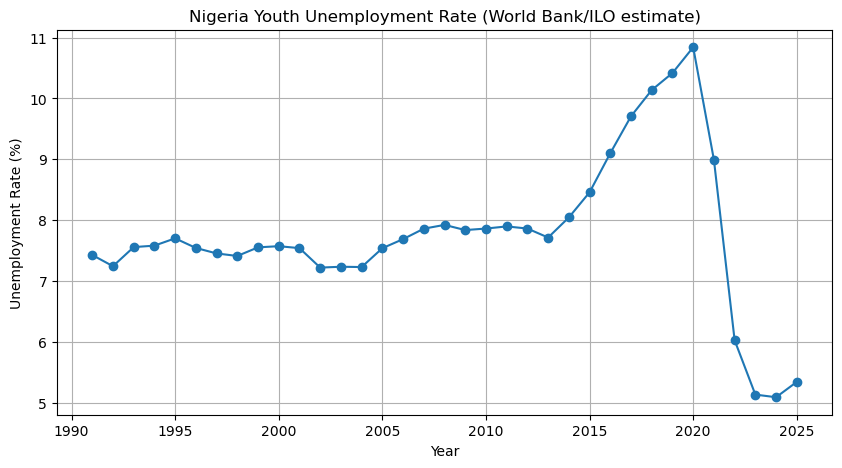

In [7]:
# Now we can all see how it looks, it's time to make our first visuals form the data above to find out the level of unemployment in Nigeria over the years
# And this is going to be from the ILO estimate. I'll talk about ILO in an article.
plt.figure(figsize=(10,5))
plt.plot(nigeria_long["Year"], nigeria_long["Youth_Unemployment_Rate"], marker="o")
plt.title("Nigeria Youth Unemployment Rate (World Bank/ILO estimate)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

In [8]:
# Now we can see from the chart above that unemployment rate fell from 2020 down to 2025 and that was because of the ICLS methodology that made Nigeria change the way it views the employment status of her citizens
# The methodology changed with the Q4 2022 NLFS rollout.
# Now, we are going to treat 2022 as the boundary year between the two regimes.
BREAK_YEAR = 2022

old_method = nigeria_long[nigeria_long["Year"] < BREAK_YEAR]
new_method = nigeria_long[nigeria_long["Year"] >= BREAK_YEAR]

print("Old methodology years:", old_method["Year"].min(), "-", old_method["Year"].max())
print("New methodology years:", new_method["Year"].min(), "-", new_method["Year"].max())

Old methodology years: 1991 - 2021
New methodology years: 2022 - 2025


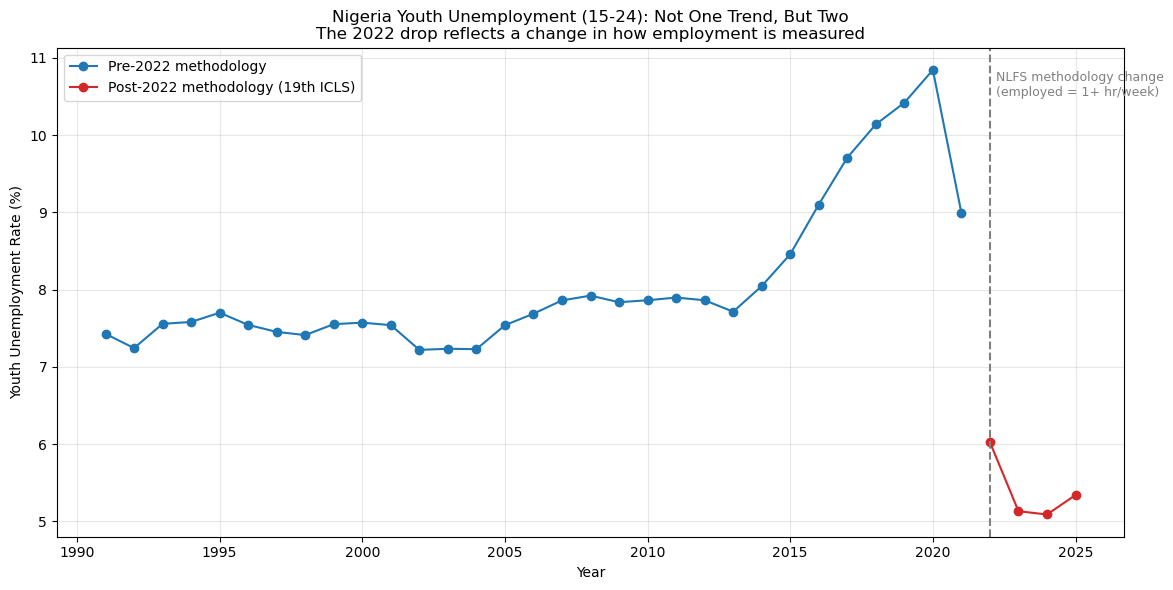

In [9]:
# I am going to use ax for everything because it allows for easy and flexible allocations and plot editing
fig, ax = plt.subplots(figsize=(12, 6))

# Two separate line calls = two separate lines, with a visible gap between them
ax.plot(old_method["Year"], old_method["Youth_Unemployment_Rate"],
        marker="o", color="#1f77b4", label="Pre-2022 methodology")
ax.plot(new_method["Year"], new_method["Youth_Unemployment_Rate"],
        marker="o", color="#d62728", label="Post-2022 methodology (19th ICLS)")

# Mark the break itself
ax.axvline(x=BREAK_YEAR, color="grey", linestyle="--", linewidth=1.5)
ax.text(BREAK_YEAR + 0.2, 10.5,
        "NLFS methodology change\n(employed = 1+ hr/week)",
        fontsize=9, color="grey")

ax.set_title("Nigeria Youth Unemployment (15-24): Not One Trend, But Two\n"
             "The 2022 drop reflects a change in how employment is measured",
             fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Youth Unemployment Rate (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section B
***Who is worst hit? The education paradox***
---
*Here we are going to really see who is affected between the Graduates or the Non-Graduates and also the employment offers available or how it is being judged*

*I'm going to enter this data manually because the NBS Q2 2024 report already has it*
*I could've easily just skipped it but this is really necessary for the analysis and this would make quite a base for this segment*

In [10]:
education_data = pd.DataFrame({
    "Education_level": ["No Education", "Primary", "Lower Secondary", "Upper Secondary", "Post Secondary"],
    "Youth_Unemployment_Rate": [5.0, 3.1, 9.5, 18.3, None],   # This is for the youth between 15-24, NBS Q2 2024 Annex A
    "NEET_Rate": [11.5, 4.8, 22.9, 19.7, None],               # And also for youths between 15-24
    "Informal_Employment_Rate": [99.0, 97.9, 94.7, 67.1, 26.6]  # This is for all workers
})

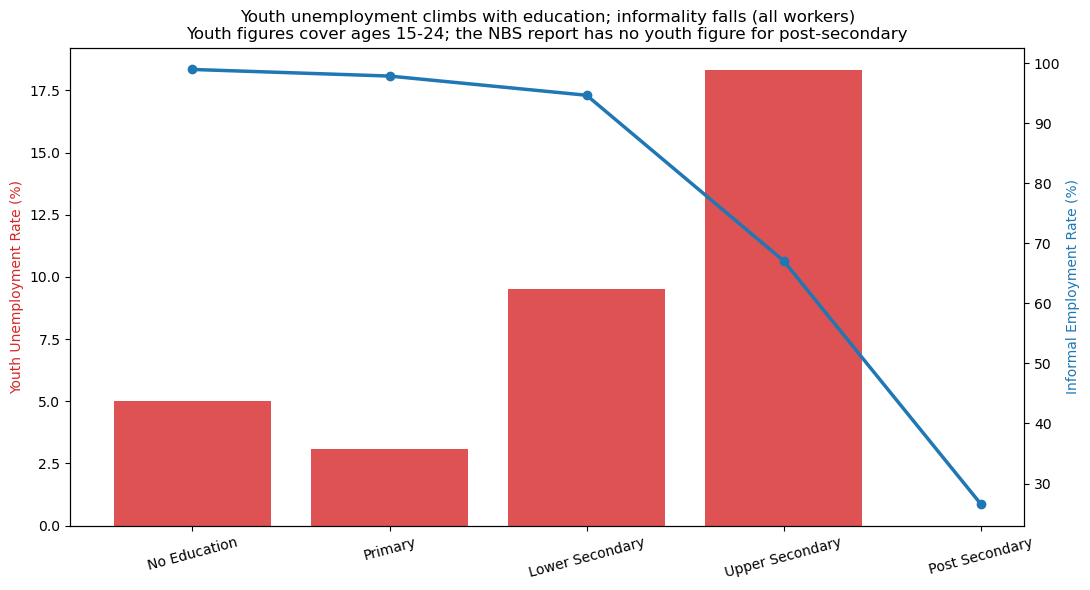

In [11]:
fig, ax1 = plt.subplots(figsize=(11, 6))

x = range(len(education_data))
ax1.bar(x, education_data["Youth_Unemployment_Rate"], color="#d62728", alpha=0.8, label="Youth Unemployment Rate (%)")
ax1.set_ylabel("Youth Unemployment Rate (%)", color="#d62728")
ax1.set_xticks(x)
ax1.set_xticklabels(education_data["Education_level"], rotation=15)

# Second y-axis sharing the same x-axis, for informality
ax2 = ax1.twinx()
ax2.plot(x, education_data["Informal_Employment_Rate"], color="#1f77b4", marker="o", linewidth=2.5, label="Informal Employment Rate (%)")
ax2.set_ylabel("Informal Employment Rate (%)", color="#1f77b4")

ax1.set_title("Youth unemployment climbs with education; informality falls (all workers)\n"
              "Youth figures cover ages 15-24; the NBS report has no youth figure for post-secondary",
              fontsize=12)
fig.tight_layout()
plt.show()

## Section C
**Now into our Forcasting Segment**
---
We are going to try to tell and test our data integrity and also provide our R-Squared from here on

In [12]:
# On this, Q4 2023 was not published in my reports, therefore we have a real gap not an error
# Youth unemployment rate (15-24), and this is gotten from NBS NLFS quarterly reports
quarterly_data = pd.DataFrame({
    "Quarter": ["Q4 2022", "Q1 2023", "Q2 2023", "Q3 2023", "Q1 2024", "Q2 2024"],
    "Quarter_Numeric": [2022.75, 2023.00, 2023.25, 2023.50, 2024.00, 2024.25],
    "Youth_Unemployment_Rate": [8.3, 6.9, 7.2, 8.6, 8.4, 6.5]
})

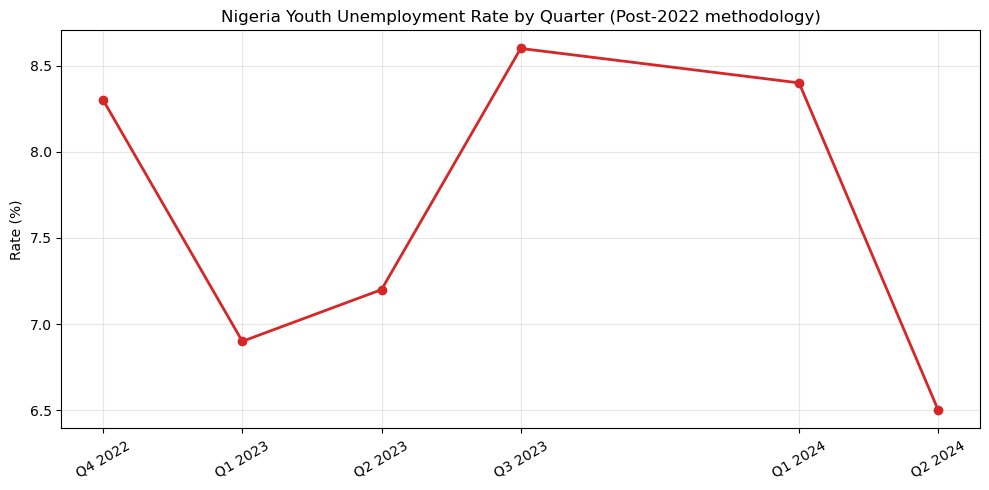

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(quarterly_data["Quarter_Numeric"], quarterly_data["Youth_Unemployment_Rate"],
        marker="o", color="#d62728", linewidth=2)
ax.set_xticks(quarterly_data["Quarter_Numeric"])
ax.set_xticklabels(quarterly_data["Quarter"], rotation=30)
ax.set_title("Nigeria Youth Unemployment Rate by Quarter (Post-2022 methodology)")
ax.set_ylabel("Rate (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Now i am going to use a regression model to try and predict our R-squared

In [15]:
from sklearn.linear_model import LinearRegression

X = quarterly_data[["Quarter_Numeric"]]
y = quarterly_data["Youth_Unemployment_Rate"]

model = LinearRegression()
model.fit(X, y)

# Does a straight line actually fit this data?, Let's find out.
r_squared = model.score(X, y)
print(f"R-squared: {r_squared:.3f}")

# Now forecasting the next 3 quarters
future_quarters = pd.DataFrame({"Quarter_Numeric": [2024.50, 2024.75, 2025.00]})
future_quarters["Predicted_Rate"] = model.predict(future_quarters[["Quarter_Numeric"]])
future_quarters["Quarter"] = ["Q3 2024", "Q4 2024", "Q1 2025"]

future_quarters

R-squared: 0.036


,Quarter_Numeric,Predicted_Rate,Quarter
0,2024.50,7.347205,Q3 2024
1,2024.75,7.274534,Q4 2024
2,2025.00,7.201863,Q1 2025


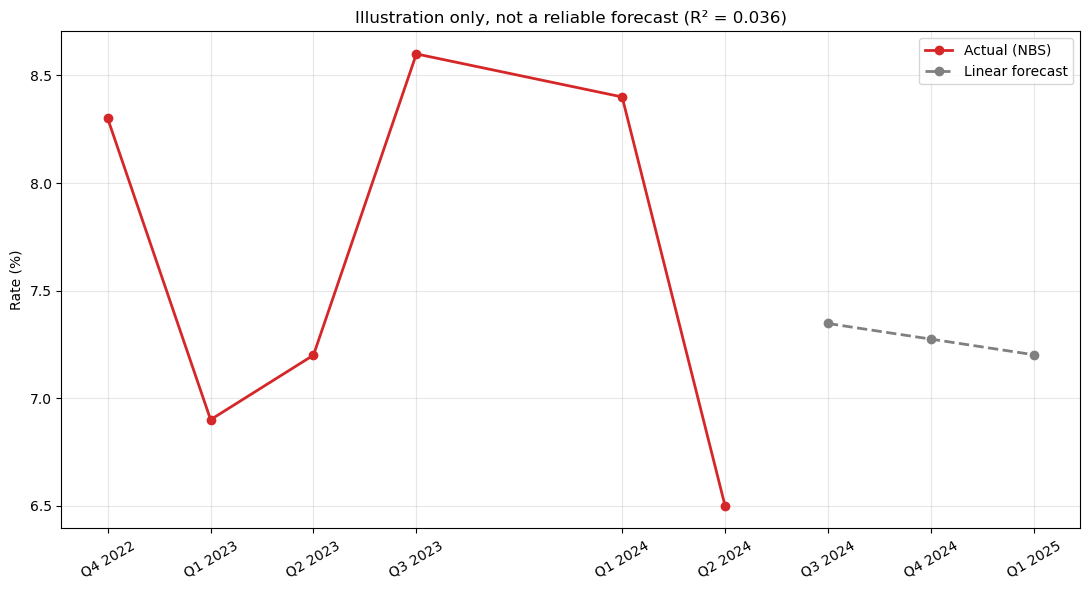

In [16]:
# Now i am going to interprete the value of our R-Squared

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(quarterly_data["Quarter_Numeric"], quarterly_data["Youth_Unemployment_Rate"],
        marker="o", color="#d62728", linewidth=2, label="Actual (NBS)")
ax.plot(future_quarters["Quarter_Numeric"], future_quarters["Predicted_Rate"],
        marker="o", linestyle="--", color="grey", linewidth=2, label="Linear forecast")

all_labels = list(quarterly_data["Quarter"]) + list(future_quarters["Quarter"])
all_x = list(quarterly_data["Quarter_Numeric"]) + list(future_quarters["Quarter_Numeric"])
ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, rotation=30)

ax.set_title(f"Illustration only, not a reliable forecast (R² = {r_squared:.3f})")
ax.set_ylabel("Rate (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Phase D: Findings and Recommendations

Each finding follows the same pattern: what the data shows, what it means, and what should be done.

---

## Finding 1: The national rate hides what young people face

**Evidence:** National unemployment in Q2 2024 was 4.3% (ages 15 and over). For ages 15 to 24 it was 6.5%. Informal work covers 93% of all employed people and 98.6% of employed youth. 12.5% of youth are NEET (not in employment, education or training).

**So what:** A low national rate does not mean young people have decent jobs. Almost all working youth are in insecure, low-protection work.

**Recommendation:** Track youth unemployment, underemployment, NEET rates and informality alongside the national rate, not instead of it.

**Audience:** NBS, policymakers, journalists

---

## Finding 2: The 2022 "improvement" is a measurement artifact

**Evidence:** In 2022, Nigeria adopted the 19th ICLS methodology, under which working 1+ hour per week counts as employed. Figures before and after are not comparable.

**So what:** The drop reflects a change in how employment is counted, not a proven improvement in the economy.

**Recommendation:** Never compare pre-2022 and post-2022 figures without flagging the methodology break.

**Audience:** Analysts, media, researchers citing this data

---

## Finding 3: Among youth, unemployment rises with education

**Evidence:** Youth (15-24) unemployment in Q2 2024: primary 3.1%, no education 5.0%, lower secondary 9.5%, upper secondary 18.3%. The report has no youth figure for post-secondary. For all ages, unemployment is 8.5% at upper secondary and 4.8% at post-secondary. Informality (all workers) falls from 99.0% to 26.6% as education rises.

**So what:** Better-educated youth may be waiting for formal jobs that are not being created fast enough. This data cannot prove that on its own.

**Recommendation:** Focus formal-sector job creation on school leavers and graduates, not only more training programs.

**Audience:** Employers, government job programs, education policy makers

---

## Finding 4: The data does not yet support a reliable forecast

**Evidence:** A linear model fit to six post-2022 quarterly points returned **R² = 0.036**. The series (8.3, 6.9, 7.2, 8.6, 8.4, 6.5) shows no consistent direction.

**So what:** The trend line explains only about 3.6% of the variation. Six noisy quarters are too few for a trustworthy prediction.

**Recommendation:** Do not publish a point forecast yet. Collect at least 8-12 consistent quarters before trying again.

**Audience:** Analysts, policymakers, anyone tempted to quote a projected rate

---

## Limitations

- Only six post-2022 quarters exist, and Q4 2023 is missing from the NBS series.
- Youth unemployment and NEET by education cover ages 15-24; informality by education covers all workers.
- Results show associations, not proven causes.
- The education table was entered by hand from the NBS Q2 2024 report.

## **Now, i am going to export all my dataset that i hand made here to my desktop so that i can visualize and create a dashboard on Power BI**

In [17]:
quarterly_data.to_csv("quarterly_youth_unemployment.csv", index=False)

In [18]:
import os

In [19]:
os.makedirs("dashboard_data", exist_ok=True)

# 1. Annual trend, labelled by methodology (for the 2022 break story)
annual = nigeria_long.copy()
annual["Methodology"] = annual["Year"].apply(
    lambda y: "Pre-2022" if y < BREAK_YEAR else "Post-2022 (19th ICLS)"
)
annual.to_csv("dashboard_data/annual_unemployment.csv", index=False)

# 2. Education table, with a sort order so Power BI keeps my sequence
edu = education_data.copy()
edu["Sort_Order"] = range(1, len(edu) + 1)
edu.to_csv("dashboard_data/education.csv", index=False)

# 3. Six post-2022 quarters (for my "no forecast" story)
quarterly_data.to_csv("dashboard_data/quarterly.csv", index=False)

# 4. The four headline numbers for my KPI cards
kpis = pd.DataFrame({
    "Metric": ["Headline youth unemployment (%)", "Youth in informal work (%)",
               "Upper secondary youth unemployment (%)", "Forecast R-squared"],
    "Value": [6.5, 98.6, 18.3, 0.036]
})

print(os.listdir("dashboard_data"))

['annual_unemployment.csv', 'education.csv', 'kpis.csv', 'quarterly.csv', 'sdg8_youth updated_dashboard.pdf', 'sdg8_youth.pbix']


In [20]:
kpis = pd.DataFrame({
    "Metric": ["Headline youth unemployment (%)", "Youth in informal work (%)",
               "Upper secondary youth unemployment (%)", "Forecast R-squared"],
    "Value": [6.5, 98.6, 18.3, 0.036]
})
kpis.to_csv("dashboard_data/kpis.csv", index=False)
print(pd.read_csv("dashboard_data/kpis.csv"))

                                   Metric   Value
0         Headline youth unemployment (%)   6.500
1              Youth in informal work (%)  98.600
2  Upper secondary youth unemployment (%)  18.300
3                      Forecast R-squared   0.036
